# 7. Hyperparameters Optimization

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from chess_eval import *

## 7.0 Introduction

For this notebook we will take each of the three classes that have passed the initial testing from notebook `6_models.ipynb` and we will optimize each one individually in a separate section. At all times, we will be using cross-validation to check for possible overfitting. At the end of each section, we will choose the subset of parameters which outputs the best result, and save these values in the `config.py` file for later recovery.

In [2]:
sm = StorageManager()
dm = load_dataset("one")

## 7.1 Ridge

For the Ridge linear model, we want to optimize the alpha $\alpha$ parameter, which is the constant that controls the regularization strength. The lower the parameter, the less regularization, the higher, the more the model tends to use fewer values, that is to drop coefficients close to zero. We will plot the metric against the alpha value using a logarithmic scale.

{'alpha': 100}

np.float64(0.519978700114284)

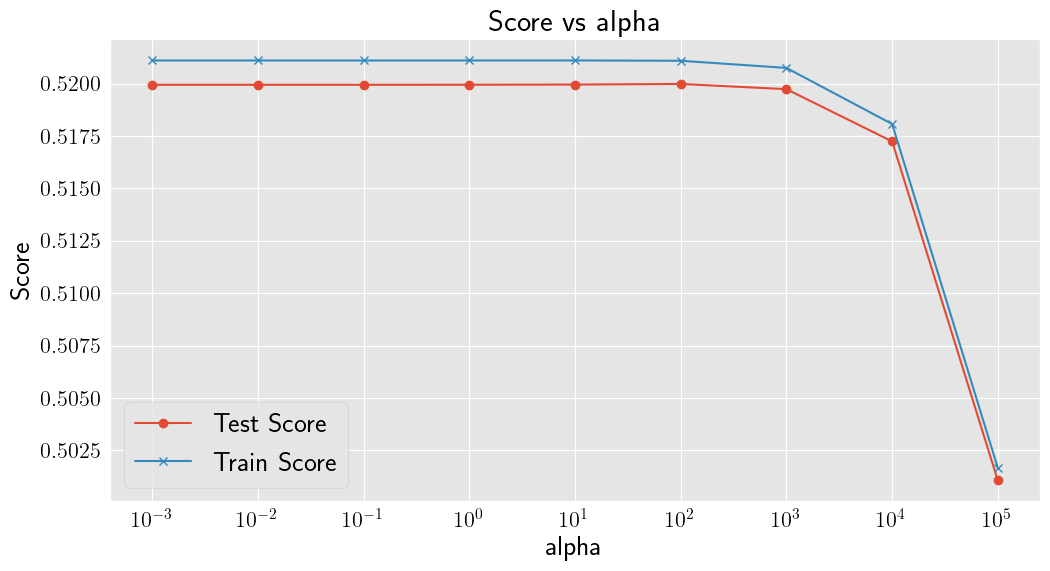

In [12]:
ridge_param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1_000, 10_000, 100_000]
}

ridge_mm = ModelManager(Ridge())

ridge_grid, ridge_best_params, ridge_best_score = ridge_mm.optimize_hyperparameters(dm, ridge_param_grid)  # ~5 seconds
display(ridge_best_params)
display(ridge_best_score)
MetricsManager.plot_gridsearch_results(ridge_grid, log=True, save=True, file="rdg")

We see that in our case, the alpha value is really not that significant. It might seem that the score has a big dip for higher values, but the logarithmic scale doesn't make justice to the scale of these numbers. Even a factor of one million ($10^{-3}\times10^6=10^3$) basically doesn't change the score. Let's take another look at lower values to see precisely what's the optimal value.

{'alpha': 100}

np.float64(0.519978700114284)

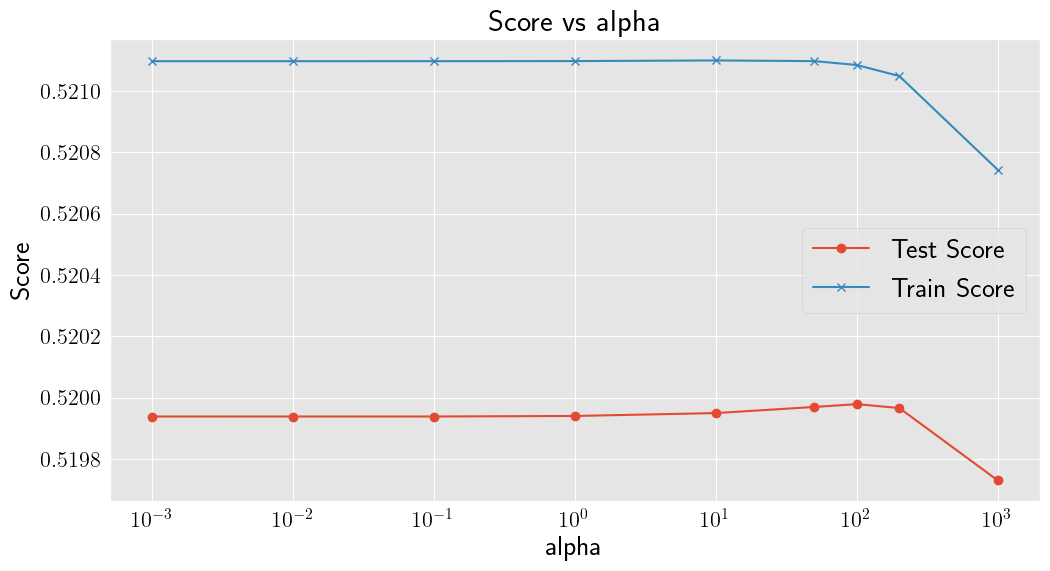

In [13]:
ridge_param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 50, 100, 200, 1_000]
}

ridge_mm = ModelManager(Ridge())

ridge_grid, ridge_best_params, ridge_best_score = ridge_mm.optimize_hyperparameters(dm, ridge_param_grid)  # ~4 seconds
display(ridge_best_params)
display(ridge_best_score)
MetricsManager.plot_gridsearch_results(ridge_grid, log=True, save=True, file="rdg", show_train=False)

We see a small rise at around $10^2$ (on the test data, on the train it takes a dip), after which the score starts going down. For that reason, we will choose the value of $\alpha=100$, as indicated by the grid-search.

## 7.2 XGBRegressor

The ExtremeGradientBoosting model has many more parameters to be optimized, but for this project we will optimize the following three: the learning rate, number of estimators and the maximum depth. Since they are all intertwined and work together to produce the final model, we cannot afford to prioritize any of these by prioritizing them by stages. We have chosen a pretty wide range of values for each of these three, but not that fine-grained as to avoid combinatorial explosion. Once we have an initial optimal set of values, we will explore each one more in depth.

{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 2000}

np.float64(0.6401259524193852)

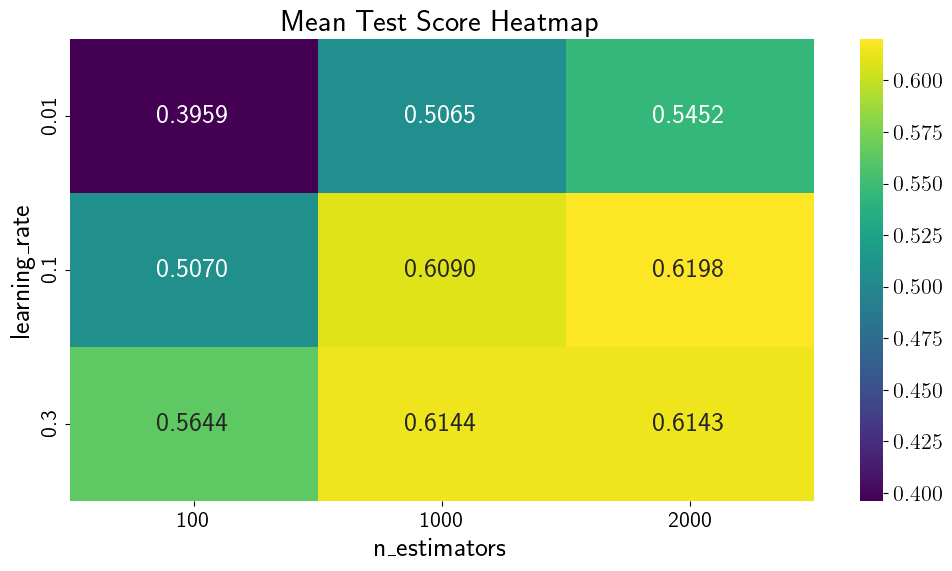

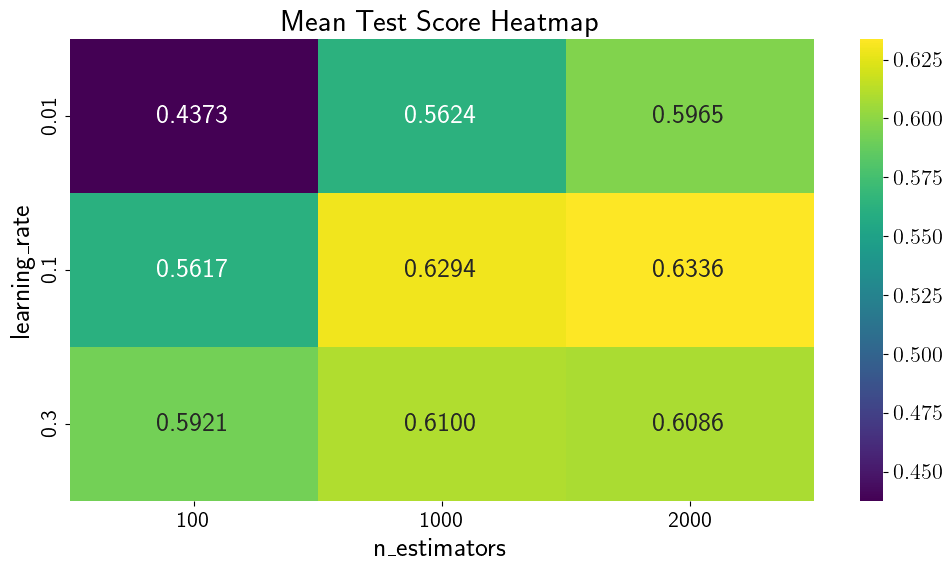

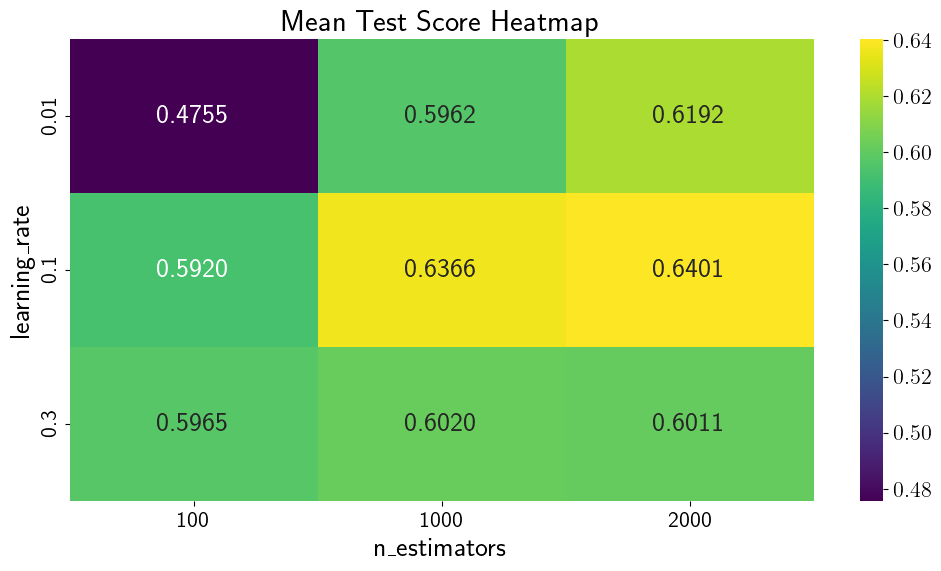

In [3]:
xgbr_mm = ModelManager(XGBRegressor())

xgbr_param_grid = {
    "learning_rate" : [0.01, 0.1, 0.3],
    "n_estimators": [100, 1000, 2000],
    "max_depth": [3, 5, 7],
}

xgbr_grid, xgbr_best_params, xgbr_best_score = xgbr_mm.optimize_hyperparameters(dm, xgbr_param_grid)  # ~8 minutes 30 seconds
display(xgbr_best_params)
display(xgbr_best_score)

for max_depth in xgbr_param_grid["max_depth"]:
    MetricsManager.plot_gridsearch_results(
        xgbr_grid,
        params={
            "learning_rate": None,
            "n_estimators": None,
            "max_depth": max_depth,
        },
        save=True,
        file="xgb"
    )

We notice that for all maximum depths the score distribution is roughly equal on the `learning_rate`-`n_estimators` plane. The higher the number of estimators, the higher the score. A huge number of estimators tends to memorize all training data, but since we're considering the mean test score after cross-validation, and we also have a big dataset, we know that the results are significant.

We will leave the maximum depth as is for now since this is one of the big factors that might enable noise memorization. The dataset we're cross-validating on is also not that big, so we will fix it to 7 (see `8_testing.ipynb` for more tests). It's pretty clear that the best learning rate is around 0.1, so let's tune the grid more finely given these considerations.

For the other two parameters, we will consider the best performing value and add grid nodes a little above and below it.

{'learning_rate': 0.05, 'n_estimators': 3000}

np.float64(0.644236678818501)

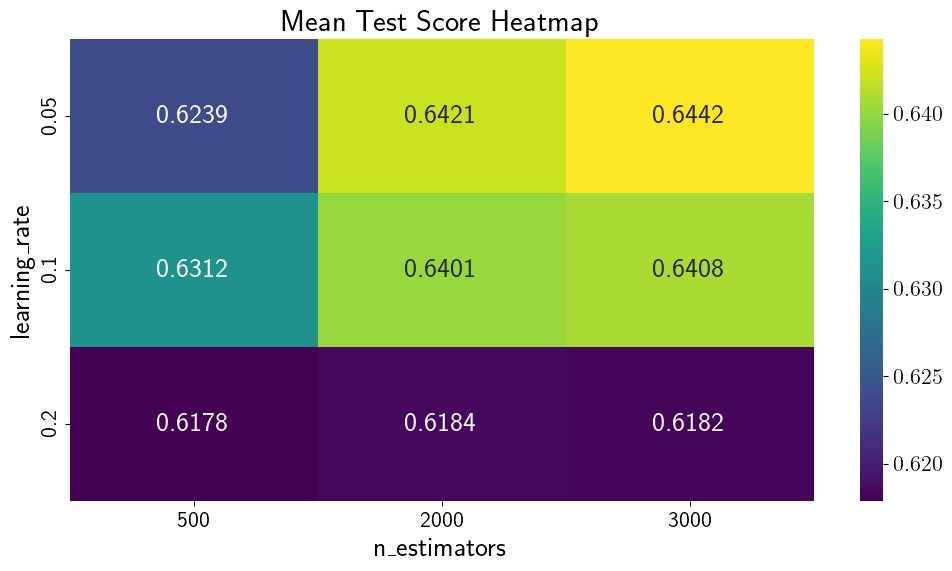

In [4]:
xgbr_mm = ModelManager(XGBRegressor(
    max_depth=7
))

xgbr_param_grid = {
    "learning_rate" : [0.05, 0.1, 0.2],
    "n_estimators": [500, 2000, 3000],
}

xgbr_grid, xgbr_best_params, xgbr_best_score = xgbr_mm.optimize_hyperparameters(dm, xgbr_param_grid)  # ~7 minutes
display(xgbr_best_params)
display(xgbr_best_score)

MetricsManager.plot_gridsearch_results(
    xgbr_grid,
    params={
        "learning_rate": None,
        "n_estimators": None,
    },
    save=True,
    file="xgb"
)

We see that pushing the number of estimators improves the score, so we will leave it a 3000. The metric is a bit higher for a learning rate of 0.05, so we will also consider it the final value.

## 7.3 KNeighborsRegressor

First, we recall that this model uses distances as its main tool to determine the prediction. That means that it works at its best when the data is normalized properly. To achieve that in a neat way and without moving our workflow around too much, we will define a pipeline that has the standard scaler as the first step before the actual KNN model.

The main parameter to be optimized in the case of the KNN model is the number of neighbors to be considered for the prediction. After various trials testing a big range of values, we have settled on this one graph that encapsulates all of our previous results.

{'knn__n_neighbors': 50}

np.float64(0.44473952828580154)

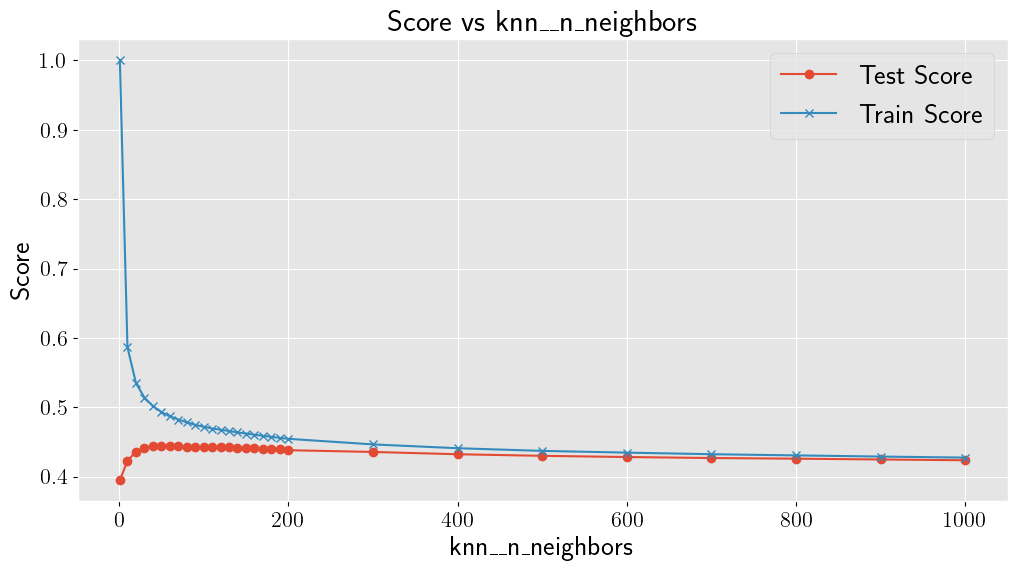

In [5]:
knn_param_grid = {
    "knn__n_neighbors": [1] + list(range(10, 200, 20)) + list(range(200, 1001, 100)),
}

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor()),
])

knn_mm = ModelManager(pipeline)

knn_grid, knn_best_params, knn_best_score = knn_mm.optimize_hyperparameters(dm, knn_param_grid)  # TODO: <1 hour (range(10, 200, 10) -> 1 hour)
display(knn_best_params)
display(knn_best_score)
MetricsManager.plot_gridsearch_results(knn_grid, save=True, file="knn")

The mean train score starts high (for $k=1$ it is a perfect prediction since it just considers the point itself as the closest neighbor), and keeps dropping: considering more neighboring points makes the average further and further away from the actual evaluation. On the other hand, at the start of the test set, the score keeps rising until it peaks more or less at the point where it meets the train score (better seen in the graph below). Then it starts to fall together with the train score. For even bigger values, it should start to lose pattern recognition and lead to model collapse, where it basically predicts around the average value all the time.

We have included more points around the maximum to better distinguish the rise and fall, but around the area of 50 to 150 the score is equal for all practical matters. Since the prediction time is proportional to $k$, and a lower value implies a generally simpler model, we believe our best pick is around 50, without a need to further tune the model.

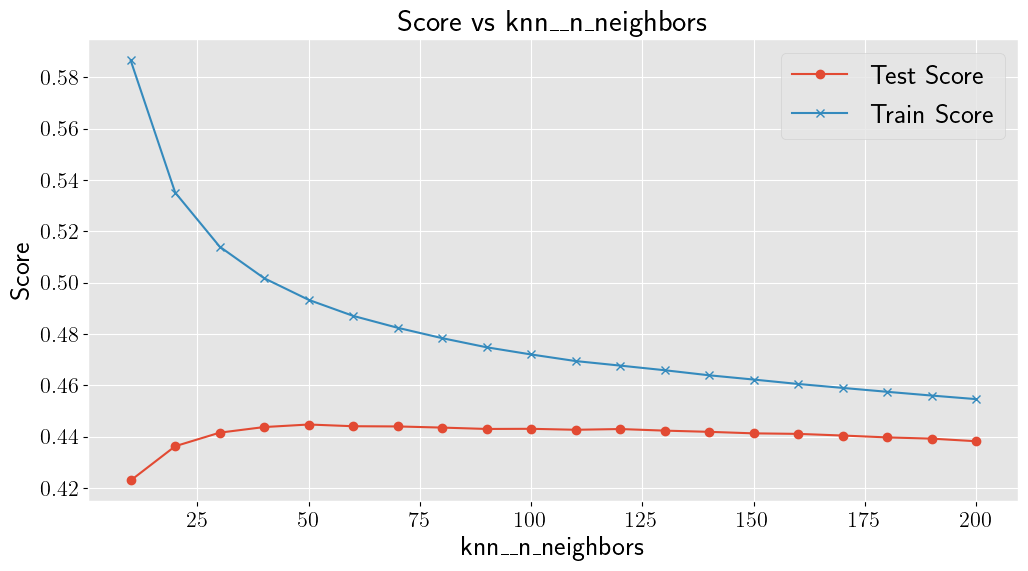

In [13]:
df = pd.DataFrame(knn_grid.cv_results_)
knn_grid_red = knn_grid
knn_grid_red.cv_results_ = df[(df["param_knn__n_neighbors"] <= 200) & (df["param_knn__n_neighbors"] > 1)].to_dict("list")
knn_grid_red.param_grid = {"knn__n_neighbors": list(range(1, 201))}
MetricsManager.plot_gridsearch_results(knn_grid, save=True, file="knn", show_train=False)

Although we thought that model should yield great results, we see that it is not the case even after hyperparameter optimization. The hypothesis of similar position in the feature space means similar evaluation might be partially true, but for all practical reasons it does not work as intended. The score is very low (compared to the other two models) and there is little room for improvement. The model is also very **slow**. Fitting-wise it might be the fastest of them all, but for a chess engine (that is normally time-constrained) what matters is prediction time. The models always come (to the game) pre-trained and only have to predict each position from the minimax algorithm. Another downside is that it is 0 scalable. The more data you have, the higher the prediction time, so adding more data might improve the model, but it will also make it much slower.

For all of these reasons, since hyperparameter optimization didn't fix the issues (as expected in the previous notebook), we think it is beyond reasonable to drop the model from the final testing.